In [80]:
import numpy as np

In [ ]:
# A predictive model jisme agr mai nye student ka data agr deta hun to wo model mujhe btayega us student ka placement hoga ya nhi !!

In [81]:
import pandas as pd

In [82]:
df = pd.read_csv("placement.csv")

In [83]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [84]:
df.shape

(100, 4)

### STEPS

##### 0. Preprocess + EDA + Feature Selection - Missing values, outliers, prepare the data to give it to your algorithm. + graphs wagera ke through aap idea lete ho ki data ke andr kya chopa hai so that aap better predictive modeling kr pao.
##### 1. Extract input and output cols 
##### 2. Scale the values - inpute colums ke values ko ek range me le aao.
##### 3. Train test split - 90 - 10 - split to check accuracy.
##### 4. train the model - use that (90) training set to train the model.
##### 5. Evaluate the model/model selection
##### 6. Deploy the model

In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [86]:
df=df.iloc[:,1:] 
# 1st : for extracting all rows from the data.
# 2nd : for extracting all columns leaving the first one.( first column has Unnamed jo ki nhi chahiye.)

In [87]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [88]:
import matplotlib.pyplot as plt   ## EDA

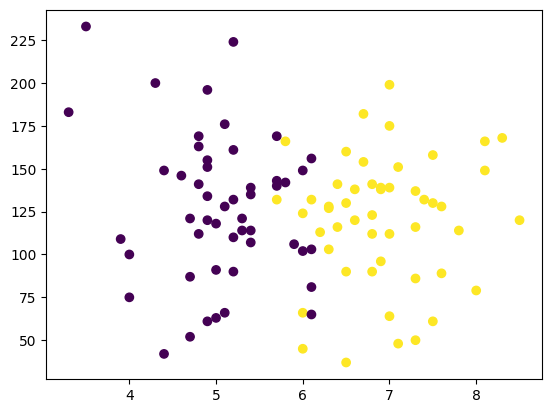

In [89]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [90]:
# Logistic Regression - a line seperation for dividing 2 things. (EDA isiliye krte hain)
# cgpa and iq are independent varibale and placement is dependent.
# df.iloc [rows,columns]

In [91]:
X = df.iloc[:,0:2]
Y = df.iloc[:,-1]

# [0:2] columns but isme 2 nhi aayega 0 se 1 tk hi aayega.
# Y me saare rows chahiye aur -1 mtlb last column chahiye.

In [92]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [93]:
Y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [94]:
Y.shape  # 1D Tensor - Vector.

(100,)

In [95]:
X.shape # 2D Tensor - Matrix.

(100, 2)

### Train Test Split

In [96]:
import sklearn

In [125]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

#### sklearn.model_selection is a library.
#### train_test_split is a function.
#### so train test split fonction me hum apne independent + dependent variable dete hain 
#### 0.1 becoz 10% data will go for testing and 90% for training.

In [126]:
X_train

,cgpa,iq
23,4.7,87.0
5,7.1,48.0
29,7.0,112.0
42,7.6,89.0
44,7.5,61.0
...,...,...
25,5.0,91.0
73,4.9,61.0
71,6.1,132.0
34,4.8,163.0


In [127]:
Y_train

23    0
5     1
29    1
42    1
44    1
     ..
25    0
73    0
71    1
34    0
41    0
Name: placement, Length: 80, dtype: int64

In [128]:
X_train = X_train.reset_index(drop=True)
Y_train = Y_train.reset_index(drop=True)

In [129]:
X_train

,cgpa,iq
0,4.7,87.0
1,7.1,48.0
2,7.0,112.0
3,7.6,89.0
4,7.5,61.0
...,...,...
75,5.0,91.0
76,4.9,61.0
77,6.1,132.0
78,4.8,163.0


In [130]:
Y_train

0     0
1     1
2     1
3     1
4     1
     ..
75    0
76    0
77    1
78    0
79    0
Name: placement, Length: 80, dtype: int64

In [131]:
X_test

,cgpa,iq
21,7.1,151.0
60,6.9,139.0
35,6.8,90.0
3,7.4,132.0
12,5.4,139.0
22,4.9,120.0
33,6.0,149.0
57,6.5,130.0
28,5.2,90.0
36,5.7,140.0


#### Scaling - range of (-1 to 1)

In [132]:
from sklearn.preprocessing import StandardScaler

In [133]:
scaler = StandardScaler()

In [134]:
X_train = scaler.fit_transform(X_train)

# fit_transform pehle smjhega data me kya hai then use transform kr dega.

In [135]:
X_train

array([[-1.07996370e+00, -8.72729241e-01],
       [ 9.13815442e-01, -1.86324042e+00],
       [ 8.30741310e-01, -2.37786177e-01],
       [ 1.32918610e+00, -8.21933796e-01],
       [ 1.24611197e+00, -1.53307003e+00],
       [-7.47667179e-01, -1.40608141e+00],
       [ 8.30741310e-02, -1.43147914e+00],
       [ 7.37846504e-16,  6.69864932e-02],
       [-6.64593048e-01, -2.88581623e-01],
       [ 1.66148262e-01, -2.12388455e-01],
       [-8.30741310e-01, -8.53998421e-02],
       [-1.66148262e+00, -1.17750191e+00],
       [ 1.07996370e+00, -1.36195287e-01],
       [ 1.07996370e+00,  3.97156886e-01],
       [ 4.15370655e-01, -7.96536074e-01],
       [-4.98444786e-01, -3.64774790e-01],
       [ 8.30741310e-01, -1.45687686e+00],
       [-1.66148262e-01,  5.24145499e-01],
       [-1.66148262e+00, -5.42558848e-01],
       [ 1.49533436e+00, -1.86990732e-01],
       [ 1.32918610e+00,  1.68577383e-01],
       [-1.41226023e+00,  1.99721341e+00],
       [-7.47667179e-01,  1.38766807e+00],
       [-2.

In [136]:
X_test = scaler.transform(X_test)

In [137]:
X_test

array([[ 9.13815442e-01,  7.52725002e-01],
       [ 7.47667179e-01,  4.47952332e-01],
       [ 6.64593048e-01, -7.96536074e-01],
       [ 1.16303783e+00,  2.70168274e-01],
       [-4.98444786e-01,  4.47952332e-01],
       [-9.13815442e-01, -3.46043970e-02],
       [ 7.37846504e-16,  7.01929557e-01],
       [ 4.15370655e-01,  2.19372829e-01],
       [-6.64593048e-01, -7.96536074e-01],
       [-2.49222393e-01,  4.73350054e-01],
       [-2.49222393e-01,  1.20988401e+00],
       [ 8.30741310e-01,  1.97181568e+00],
       [-1.32918610e+00, -2.01562676e+00],
       [-9.13815442e-01,  8.54315892e-01],
       [-6.64593048e-01,  2.60675875e+00],
       [-2.49222393e-01,  2.70168274e-01],
       [ 7.37846504e-16, -1.40608141e+00],
       [-4.98444786e-01,  3.46361441e-01],
       [ 4.98444786e-01, -3.46043970e-02],
       [ 2.49222393e-01,  1.43179661e-01]])

In [138]:
from sklearn.linear_model import LogisticRegression

# sklearn.linearmodel is a model and linear regression is a class .

In [139]:
clf= LogisticRegression()

# clf is a L.R. object

#### Model Training

In [140]:
clf.fit(X_train,Y_train)  

#dataset chota hai to model turant train ho gya.
# Neural Networks me jaada mja aata hai.

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

### Model Evaluation.

#### Accuracy nikal lete hain test wale data par.

In [141]:
Y_pred = clf.predict(X_test)

In [142]:
Y_test

21    1
60    1
35    1
3     1
12    0
22    0
33    0
57    1
28    0
36    0
84    0
26    1
96    0
76    0
16    0
87    1
45    1
49    0
20    1
70    1
Name: placement, dtype: int64

In [143]:
Y_pred

array([1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1])

In [144]:
from sklearn.metrics import accuracy_score

# accuracy score new function jisme shi wala data aur jo predict krna h dono dena hota hai.

In [146]:
accuracy_score(Y_test,Y_pred)

0.85

#### How to plot decision boundary - ML model ne kya pattern notice kiya aapke data me usko agr aapko visualise krna h to aap isse kr skte ho.

In [147]:
from mlxtend.plotting import plot_decision_regions

In [148]:
!pip install mlxtend

<Axes: >

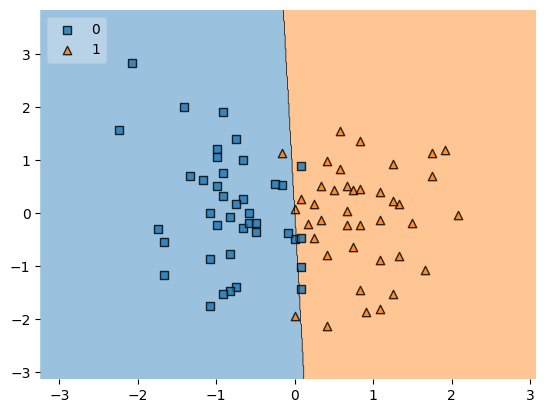

In [149]:
plot_decision_regions(X_train, Y_train.values, clf=clf, legend=2)

In [150]:
import pickle 
# Python me everything is an object.
# Pickle object ko file me convert kr deta hai.
# Object to file converter u can use that file in any other environment.

In [151]:
pickle.dump(clf,open('model.pkl','wb'))

In [152]:
!pip install gradio

In [154]:
import gradio as gr

def predict(iq, cgpa):
    input_data = [[cgpa, iq]]
    input_data = scaler.transform(input_data)

    result = clf.predict(input_data)
    
    if result[0] == 1:
        return "Placement Ho Jaayega 🎉"
    else:
        return "Placement Nahi Hoga 😔"

demo = gr.Interface(
    fn=predict,
    inputs=[
        gr.Number(label="Enter IQ of the student"),
        gr.Number(label="Enter CGPA of the student")
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="Placement Predictor"
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


C:\Users\Hp\anaconda3\envs\100daysofML\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Hp\anaconda3\envs\100daysofML\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Hp\anaconda3\envs\100daysofML\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Hp\anaconda3\envs\100daysofML\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Hp\anaconda3\envs\100daysofML\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted w